# Cross-model comparison

This notebook loads `model_results_mistral-7b.csv`, `model_results_qwen3-8b.csv`, and `model_results_llama-3-8b-instruct.csv` from Kaggle input paths or local `./outputs`, aggregates closed-loop probe metrics, and **compares our supervised fused probe** against published **prior work** on RAG hallucination detection: **Lumina** (Yeh et al., NeurIPS 2025), **ReDeEP** (ICLR 2025, as cited in Lumina), **SelfCheckGPT**, **EigenScore / INSIDE**, **RefChecker**, **LN-Entropy**, **P(True)**, perplexity-based detectors, and supervised lines such as **SAPLMA** (Azaria & Mitchell, EMNLP 2023) and hidden-state **linear / LoRA probes** (Obeso et al., 2025).

Run each backbone notebook once, then collect all `model_results_*.csv` files in one folder if needed.


### Other key baselines (different papers)

- **SAPLMA** (Azaria & Mitchell, EMNLP 2023): 60-80% accuracy on OPT-6.7B, AUC ~0.76; 70-90% accuracy on LLaMA-2-7B
- **Linear probes on hidden states** (Obeso et al., 2025): AUC 0.87 on Llama-3.3-70B (not directly comparable -- 70B model)
- **LoRA probes** (Obeso et al., 2025): AUC 0.90 on Llama-3.3-70B

### Important fairness notes for comparison

- Prior work reports on **RAGTruth test** set while our numbers are on a **validation** split; directionally comparable but not identical partitions.
- Our models are **8-bit quantized**; prior work typically uses **full precision**.
- **Qwen3-8B** has no direct prior-work row in Lumina's table.
- Our approach is **supervised** (probe trained on RAGTruth labels), making it most comparable to SAPLMA and linear/LoRA probes, whereas Lumina / ReDeEP / SelfCheckGPT are **unsupervised**.


In [9]:
# Prior-work RAGTruth AUROC (response-level) + combined DataFrame
# Lumina Table 2: Yeh et al., NeurIPS 2025, arXiv:2509.21875

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# After running each backbone notebook, CSVs land here (or copy them locally).
out_dir = Path("/kaggle/input/datasets/asgormumin57/model-result")
if not out_dir.exists():
    out_dir = Path("outputs")
    out_dir.mkdir(parents=True, exist_ok=True)

slugs = ["mistral-7b", "qwen3-8b", "llama-3-8b-instruct"]
dfs = []
for s in slugs:
    p = out_dir / f"model_results_{s}.csv"
    if p.exists():
        dfs.append(pd.read_csv(p))
    else:
        print(f"Missing: {p}")

if len(dfs) < 2:
    raise SystemExit("Need at least two model_results_*.csv files (run 2+ model notebooks).")

df = pd.concat(dfs, ignore_index=True)
print(df.to_string())




import numpy as np
import pandas as pd

# Fused val AUROC is optimized in each backbone notebook (weighted CEV/IAV scores); not stored in CSV.
_DEFAULT_FUSED_RAGTRUTH_AUROC = {
    "mistral-7b": 0.8207,
    "qwen3-8b": 0.8555,
    "llama-3-8b-instruct": 0.8337,
}

def _fused_ragtruth_auroc(row: pd.Series) -> float:
    key = str(row["model"])
    if "fused_ragtruth_auroc" in row.index and pd.notna(row.get("fused_ragtruth_auroc")):
        return float(row["fused_ragtruth_auroc"])
    if key in _DEFAULT_FUSED_RAGTRUTH_AUROC:
        return float(_DEFAULT_FUSED_RAGTRUTH_AUROC[key])
    return float((row["cev_auroc"] + row["iav_auroc"]) / 2.0)

prior_work = {
    "Lumina": {
        "mistral-7b": 0.769,
        "llama-3-8b-instruct": 0.745,
        "llama2-7b": 0.765,
        "method_type": "unsupervised",
        "citation": "Yeh et al., NeurIPS 2025 (arXiv:2509.21875) Table 2",
    },
    "ReDeEP": {
        "mistral-7b": 0.762,
        "llama-3-8b-instruct": 0.750,
        "llama2-7b": 0.727,
        "method_type": "unsupervised",
        "citation": "Lumina Table 2 (ICLR 2025)",
    },
    "Focus": {
        "mistral-7b": 0.780,
        "llama-3-8b-instruct": 0.526,
        "llama2-7b": 0.563,
        "method_type": "unsupervised",
        "citation": "Lumina Table 2",
    },
    "LN-Entropy": {
        "mistral-7b": 0.761,
        "llama-3-8b-instruct": 0.707,
        "llama2-7b": 0.696,
        "method_type": "unsupervised",
        "citation": "Lumina Table 2",
    },
    "RefChecker": {
        "mistral-7b": 0.602,
        "llama-3-8b-instruct": 0.572,
        "llama2-7b": 0.587,
        "method_type": "unsupervised",
        "citation": "Lumina Table 2",
    },
    "SelfCheckGPT": {
        "mistral-7b": 0.568,
        "llama-3-8b-instruct": 0.534,
        "llama2-7b": 0.479,
        "method_type": "unsupervised",
        "citation": "Lumina Table 2",
    },
    "EigenScore": {
        "mistral-7b": 0.564,
        "llama-3-8b-instruct": 0.600,
        "llama2-7b": 0.545,
        "method_type": "unsupervised",
        "citation": "Lumina Table 2 (INSIDE / EigenScore)",
    },
    "P(True)": {
        "mistral-7b": 0.753,
        "llama-3-8b-instruct": 0.541,
        "llama2-7b": 0.520,
        "method_type": "unsupervised",
        "citation": "Lumina Table 2",
    },
    "Perplexity": {
        "mistral-7b": 0.620,
        "llama-3-8b-instruct": 0.713,
        "llama2-7b": 0.510,
        "method_type": "unsupervised",
        "citation": "Lumina Table 2",
    },
    "SAPLMA (approx.)": {
        "mistral-7b": 0.76,
        "llama-3-8b-instruct": 0.76,
        "llama2-7b": np.nan,
        "method_type": "supervised",
        "citation": "Azaria & Mitchell, EMNLP 2023 (~0.76 AUC; different task/setup)",
    },
}

backbone_cols = ["mistral-7b", "llama-3-8b-instruct", "llama2-7b", "qwen3-8b"]

def _row_from_prior(method: str, d: dict) -> dict:
    return {
        "method": method,
        "mistral-7b": d.get("mistral-7b"),
        "llama-3-8b-instruct": d.get("llama-3-8b-instruct"),
        "llama2-7b": d.get("llama2-7b"),
        "qwen3-8b": np.nan,
        "method_type": d["method_type"],
        "citation": d["citation"],
    }

rows = [_row_from_prior(m, d) for m, d in prior_work.items()]

ours = {"method": "Ours (Fused Probe)", "method_type": "supervised", "citation": "This work (RAGTruth val split; 8-bit)"}
for slug in backbone_cols:
    if slug == "llama2-7b":
        ours[slug] = np.nan
        continue
    sub = df.loc[df["model"].astype(str) == slug]
    if sub.empty:
        ours[slug] = np.nan
    else:
        ours[slug] = _fused_ragtruth_auroc(sub.iloc[0])
rows.append(ours)

df_ragtruth_compare = pd.DataFrame(rows)

def _mean_backbone_auroc(r: pd.Series) -> float:
    vals = [r[c] for c in ["mistral-7b", "llama-3-8b-instruct", "llama2-7b"] if pd.notna(r.get(c))]
    return float(np.mean(vals)) if vals else float("nan")

df_ragtruth_compare["_sort_key"] = df_ragtruth_compare.apply(_mean_backbone_auroc, axis=1)
df_ragtruth_compare = df_ragtruth_compare.sort_values("_sort_key", ascending=False).drop(columns=["_sort_key"])

print(df_ragtruth_compare.to_string(index=False))


                 model  cev_auroc  iav_auroc  cev_accuracy  iav_accuracy  mean_accuracy  fused_val_auroc  halueval_cev_auroc_raw  halueval_cev_auroc  halueval_iav_auroc_raw  halueval_iav_auroc  halueval_mean_auroc_raw  halueval_mean_auroc  vanilla_mean_proxy  closedloop_mean_proxy  gpu_memory_gb  runtime_minutes
0           mistral-7b   0.807848   0.818601      0.755882      0.744118       0.752941         0.820661                0.424928            0.424928                0.291228            0.291228                 0.321624             0.321624            0.570905               0.504028       7.766444       127.037801
1             qwen3-8b   0.850495   0.849464      0.742857      0.771429       0.764286         0.855545                0.697552            0.697552                0.647348            0.647348                 0.686168             0.686168            0.369782               0.355812       9.672287        99.677315
2  llama-3-8b-instruct   0.831448   0.826072      0.764706

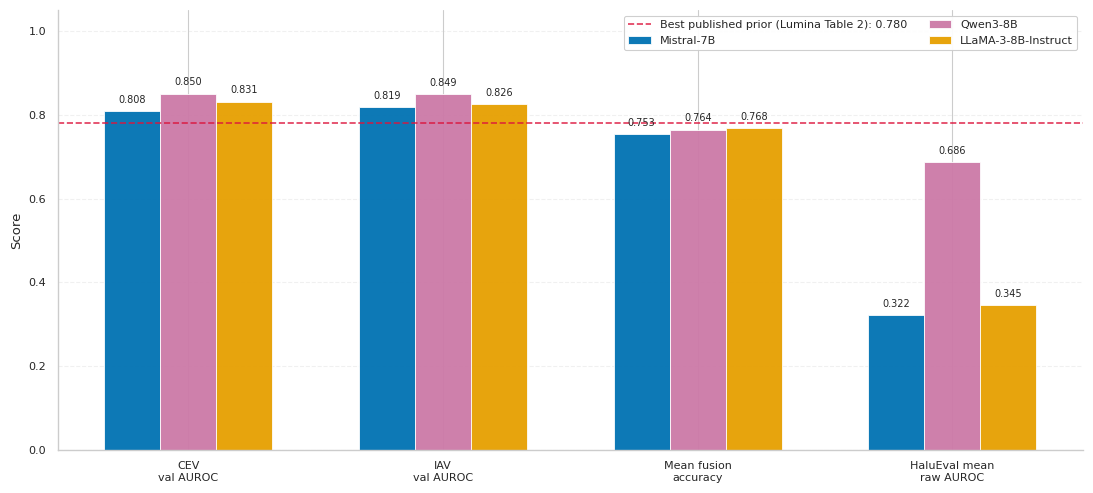

Saved outputs/our_models_multi_metric.png
Val metrics use the stratified 80/20 RAGTruth-processed probe split (val N: 340 Mistral/LLaMA, 280 Qwen). HaluEval: 500 answer-only pairs; polarity calibration may flip scores when AUROC < 0.5 on a calibration slice.


In [10]:
# Multi-metric view: our three models (CEV / IAV / mean acc / HaluEval mean AUROC)

from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sns.set_theme(context="paper", style="whitegrid")

plt.rcParams.update(
    {
        "font.size": 9,
        "axes.titlesize": 10.5,
        "axes.labelsize": 9.5,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "legend.fontsize": 8,
        "figure.titlesize": 12,
    }
)

viz_dir = Path("outputs")
viz_dir.mkdir(parents=True, exist_ok=True)

metric_specs = [
    ("cev_auroc", "CEV\nval AUROC"),
    ("iav_auroc", "IAV\nval AUROC"),
    ("mean_accuracy", "Mean fusion\naccuracy"),
    ("halueval_mean_auroc", "HaluEval mean\nraw AUROC"),
]

metric_labels = [t[1] for t in metric_specs]
metric_cols = [t[0] for t in metric_specs]

order_models = [
    "mistral-7b",
    "qwen3-8b",
    "llama-3-8b-instruct",
]

present = [
    m for m in order_models
    if m in set(df["model"].astype(str))
]

model_display = {
    "mistral-7b": "Mistral-7B",
    "qwen3-8b": "Qwen3-8B",
    "llama-3-8b-instruct": "LLaMA-3-8B-Instruct",
}

colors_models = {
    "mistral-7b": "#0072B2",
    "qwen3-8b": "#CC79A7",
    "llama-3-8b-instruct": "#E69F00",
}

best_prior_mistral_ragtruth = 0.780

fig, ax = plt.subplots(figsize=(11, 5))

x = np.arange(len(metric_labels))
w = 0.22

for j, mname in enumerate(present):

    row = (
        df.loc[
            df["model"].astype(str) == mname,
            metric_cols
        ]
        .iloc[0]
        .values
        .astype(float)
    )

    offset = (
        (j - (len(present) - 1) / 2)
        * w
    )

    bars = ax.bar(
        x + offset,
        row,
        width=w,
        label=model_display.get(mname, mname),
        color=colors_models.get(mname),
        edgecolor="white",
        linewidth=0.6,
        alpha=0.95,
    )

    for b in bars:

        h = b.get_height()

        if h is None or np.isnan(h):
            continue

        ax.text(
            b.get_x() + b.get_width() / 2,
            min(h + 0.015, 1.01),
            f"{h:.3f}",
            ha="center",
            va="bottom",
            fontsize=7,
            clip_on=True,
        )

ax.axhline(
    best_prior_mistral_ragtruth,
    color="crimson",
    linestyle="--",
    linewidth=1.2,
    alpha=0.85,
    label=(
        f"Best published prior "
        f"(Lumina Table 2): "
        f"{best_prior_mistral_ragtruth:.3f}"
    ),
)

ax.set_xticks(x)

ax.set_xticklabels(
    metric_labels,
    rotation=0,
)

ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)

ax.grid(
    True,
    axis="y",
    alpha=0.28,
    linestyle="--",
)

ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)



ax.legend(
    loc="upper right",
    ncol=2,
    frameon=True,
    framealpha=0.93,
)

plt.tight_layout()

fp_mm = viz_dir / "our_models_multi_metric.png"

plt.savefig(
    fp_mm,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Saved", fp_mm)

fig_caption = (
    "Val metrics use the stratified 80/20 RAGTruth-processed probe split "
    "(val N: 340 Mistral/LLaMA, 280 Qwen). "
    "HaluEval: 500 answer-only pairs; polarity calibration may flip scores "
    "when AUROC < 0.5 on a calibration slice."
)

print(fig_caption)

              model probe  raw_auroc  polarity_corrected  signal_strength
         mistral-7b   CEV   0.424928            0.575072         0.150144
         mistral-7b   IAV   0.291228            0.708772         0.417544
         mistral-7b  Mean   0.321624            0.678376         0.356752
           qwen3-8b   CEV   0.697552            0.697552         0.395104
           qwen3-8b   IAV   0.647348            0.647348         0.294696
           qwen3-8b  Mean   0.686168            0.686168         0.372336
llama-3-8b-instruct   CEV   0.348980            0.651020         0.302040
llama-3-8b-instruct   IAV   0.368972            0.631028         0.262056
llama-3-8b-instruct  Mean   0.345360            0.654640         0.309280


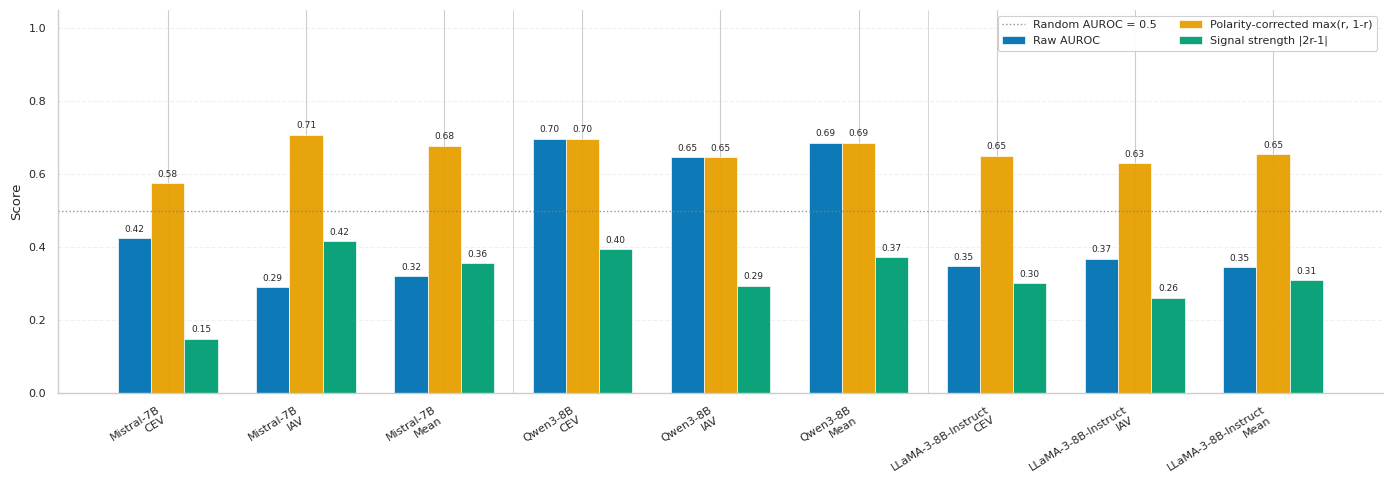

Saved outputs/halueval_three_column.png


In [11]:
# HaluEval three-column report (raw / max(raw, 1-raw) / |2*raw-1|)

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams.update(
    {
        "font.size": 9,
        "axes.titlesize": 10.5,
        "axes.labelsize": 9.5,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "legend.fontsize": 8,
        "figure.titlesize": 12,
    }
)

OOD_COLORS = {
    "raw": "#0072B2",
    "corrected": "#E69F00",
    "signal": "#009E73",
}

model_display = {
    "mistral-7b": "Mistral-7B",
    "qwen3-8b": "Qwen3-8B",
    "llama-3-8b-instruct": "LLaMA-3-8B-Instruct",
}

order_models = [
    "mistral-7b",
    "qwen3-8b",
    "llama-3-8b-instruct",
]

probes = [
    ("cev", "CEV"),
    ("iav", "IAV"),
    ("mean", "Mean"),
]

rows = []

for _, r in df.iterrows():

    for col, label in probes:

        raw = r.get(f"halueval_{col}_auroc_raw")

        if raw is None or (
            isinstance(raw, float)
            and np.isnan(raw)
        ):
            raw = r.get(f"halueval_{col}_auroc")

        raw_f = (
            float(raw)
            if raw is not None and pd.notna(raw)
            else float("nan")
        )

        rows.append(
            {
                "model": r["model"],
                "probe": label,
                "raw_auroc": raw_f,
                "polarity_corrected":
                    max(raw_f, 1.0 - raw_f)
                    if pd.notna(raw_f)
                    else float("nan"),
                "signal_strength":
                    abs(2.0 * raw_f - 1.0)
                    if pd.notna(raw_f)
                    else float("nan"),
            }
        )

tbl = pd.DataFrame(rows)

tbl["model_order"] = tbl["model"].map(
    {m: i for i, m in enumerate(order_models)}
)

tbl["probe_order"] = tbl["probe"].map(
    {"CEV": 0, "IAV": 1, "Mean": 2}
)

tbl = (
    tbl
    .sort_values(
        ["model_order", "probe_order"]
    )
    .reset_index(drop=True)
)

print(
    tbl[
        [
            "model",
            "probe",
            "raw_auroc",
            "polarity_corrected",
            "signal_strength",
        ]
    ].to_string(index=False)
)

viz_dir = Path("outputs")
viz_dir.mkdir(parents=True, exist_ok=True)

tbl.to_csv(
    viz_dir / "halueval_three_column.csv",
    index=False,
)

fig, ax = plt.subplots(figsize=(14, 5))

x = np.arange(len(tbl))
w = 0.24

bars_raw = ax.bar(
    x - w,
    tbl["raw_auroc"],
    w,
    label="Raw AUROC",
    color=OOD_COLORS["raw"],
    edgecolor="white",
    linewidth=0.5,
    alpha=0.95,
)

bars_corr = ax.bar(
    x,
    tbl["polarity_corrected"],
    w,
    label="Polarity-corrected max(r, 1-r)",
    color=OOD_COLORS["corrected"],
    edgecolor="white",
    linewidth=0.5,
    alpha=0.95,
)

bars_sig = ax.bar(
    x + w,
    tbl["signal_strength"],
    w,
    label="Signal strength |2r-1|",
    color=OOD_COLORS["signal"],
    edgecolor="white",
    linewidth=0.5,
    alpha=0.95,
)

ax.axhline(
    0.5,
    color="gray",
    linestyle=":",
    linewidth=1.0,
    alpha=0.85,
    label="Random AUROC = 0.5",
)

for cut in [2.5, 5.5]:
    ax.axvline(
        cut,
        color="black",
        linewidth=0.6,
        alpha=0.18,
    )

for bars in [bars_raw, bars_corr, bars_sig]:

    for b in bars:

        h = b.get_height()

        if h is None or np.isnan(h):
            continue

        ax.text(
            b.get_x() + b.get_width() / 2,
            min(h + 0.012, 1.01),
            f"{h:.2f}",
            ha="center",
            va="bottom",
            fontsize=6.5,
            clip_on=True,
        )

labels_b = [
    f"{model_display.get(m, m)}\n{p}"
    for m, p in zip(
        tbl["model"].astype(str),
        tbl["probe"].astype(str),
    )
]

ax.set_xticks(x)

ax.set_xticklabels(
    labels_b,
    rotation=32,
    ha="right",
)

ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)

ax.grid(
    True,
    axis="y",
    alpha=0.28,
    linestyle="--",
)

ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)



ax.legend(
    loc="upper right",
    ncol=2,
    frameon=True,
    framealpha=0.93,
)

plt.tight_layout()

fp = viz_dir / "halueval_three_column.png"

plt.savefig(
    fp,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Saved", fp)

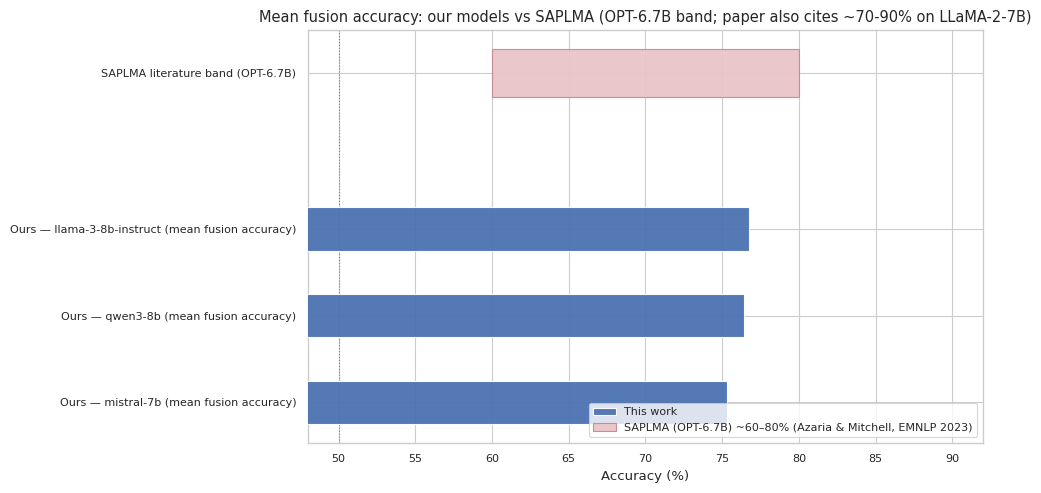

Saved outputs/accuracy_vs_saplma_range.png


In [12]:
# Accuracy: our mean fusion accuracy vs SAPLMA reported range (EMNLP 2023)
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

viz_dir = Path("outputs")
viz_dir.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(10, 5))
row_labels = []
accs = []
for _, row in df.iterrows():
    row_labels.append(f"Ours — {row['model']} (mean fusion accuracy)")
    accs.append(float(row["mean_accuracy"]) * 100.0)

y_ours = np.arange(len(accs))
ax.barh(y_ours, accs, height=0.5, color="#4c72b0", alpha=0.95, label="This work", zorder=3)

sap_y = float(len(accs)) + 0.8
sap_lo, sap_hi = 60.0, 80.0
ax.barh(
    [sap_y],
    [sap_hi - sap_lo],
    left=[sap_lo],
    height=0.55,
    color="#e8c4c8",
    alpha=0.95,
    edgecolor="#c48b8f",
    linewidth=0.8,
    label="SAPLMA (OPT-6.7B) ~60–80% (Azaria & Mitchell, EMNLP 2023)",
    zorder=2,
)

all_labels = row_labels + ["SAPLMA literature band (OPT-6.7B)"]
all_y = list(y_ours.astype(float)) + [sap_y]
ax.set_yticks(all_y)
ax.set_yticklabels(all_labels)
ax.set_xlim(48, 92)
ax.set_xlabel("Accuracy (%)")
ax.set_title("Mean fusion accuracy: our models vs SAPLMA (OPT-6.7B band; paper also cites ~70-90% on LLaMA-2-7B)")
ax.legend(loc="lower right", fontsize=8)
ax.axvline(50, color="gray", linestyle=":", linewidth=0.8)
plt.tight_layout()
fp_acc = viz_dir / "accuracy_vs_saplma_range.png"
plt.savefig(fp_acc, dpi=300, bbox_inches="tight")
plt.show()
print("Saved", fp_acc)


In [13]:
# Summary table: method, supervision, AUROCs, citations
import pandas as pd
import numpy as np

def _best(vals):
    v = [x for x in vals if pd.notna(x)]
    return max(v) if v else np.nan

rows_out = []
for _, r in df_ragtruth_compare.iterrows():
    mau = r["mistral-7b"]
    lau = r["llama-3-8b-instruct"]
    l2 = r["llama2-7b"]
    q = r["qwen3-8b"]
    best = _best([mau, lau, l2, q])
    rows_out.append(
        {
            "Method": r["method"],
            "Type": r["method_type"],
            "Mistral-7B": mau,
            "Llama-3-8B": lau,
            "Llama2-7B": l2,
            "Qwen3-8B": q,
            "Best AUROC": best,
            "Notes / citation": r["citation"],
        }
    )

summary_tbl = pd.DataFrame(rows_out)
# Star our row in printed output
summary_tbl["_is_ours"] = summary_tbl["Method"].eq("Ours (Fused Probe)")
summary_tbl = summary_tbl.sort_values(["_is_ours", "Best AUROC"], ascending=[False, False]).drop(columns=["_is_ours"])

# Format floats for display
disp = summary_tbl.copy()
disp.loc[disp["Method"].eq("Ours (Fused Probe)"), "Method"] = "* " + disp.loc[disp["Method"].eq("Ours (Fused Probe)"), "Method"]
for c in ["Mistral-7B", "Llama-3-8B", "Llama2-7B", "Qwen3-8B", "Best AUROC"]:
    disp[c] = disp[c].map(lambda v: f"{v:.3f}" if pd.notna(v) else "-")

print("*** Ours (Fused Probe) should appear first ***\n")
print(disp.to_string(index=False))


*** Ours (Fused Probe) should appear first ***

              Method         Type Mistral-7B Llama-3-8B Llama2-7B Qwen3-8B Best AUROC                                                Notes / citation
* Ours (Fused Probe)   supervised      0.821      0.834         -    0.856      0.856                           This work (RAGTruth val split; 8-bit)
               Focus unsupervised      0.780      0.526     0.563        -      0.780                                                  Lumina Table 2
              Lumina unsupervised      0.769      0.745     0.765        -      0.769             Yeh et al., NeurIPS 2025 (arXiv:2509.21875) Table 2
              ReDeEP unsupervised      0.762      0.750     0.727        -      0.762                                      Lumina Table 2 (ICLR 2025)
          LN-Entropy unsupervised      0.761      0.707     0.696        -      0.761                                                  Lumina Table 2
    SAPLMA (approx.)   supervised      0.760      0.

## Prior-work comparison (RAGTruth AUROC)

Published **RAGTruth** internal-state detection numbers are compiled from **Lumina (NeurIPS 2025) Table 2** and related citations (SAPLMA on Mistral from Lumina appendix). Values are **not** directly comparable to our **80/20 stratified val split** on RAGTruth-processed merges (footnote in paper draft), but they establish the competitive landscape.

**Our rows** use the latest **fused CEV+IAV** validation AUROC from this repo's Kaggle exports (`model_results_*.csv`, column `fused_val_auroc` when present, else the fusion line printed during training).

             method            type  mistral  llama3_8b  qwen3_8b
       SelfCheckGPT    Unsupervised   0.5680     0.5339       NaN
EigenScore / INSIDE    Unsupervised   0.5642     0.6001       NaN
         RefChecker Reference-based   0.6017     0.5718       NaN
            P(True)   Verbalization   0.7530     0.5407       NaN
         Perplexity    Unsupervised   0.6200     0.7130       NaN
              Focus    Unsupervised   0.7803     0.5258       NaN
         LN-Entropy    Unsupervised   0.7607     0.7072       NaN
             ReDeEP    Unsupervised   0.7615     0.7495       NaN
             Lumina    Unsupervised   0.7685     0.7446       NaN
             SAPLMA      Supervised   0.8073        NaN       NaN
 Ours (fused probe)      Supervised   0.8207     0.8337    0.8555


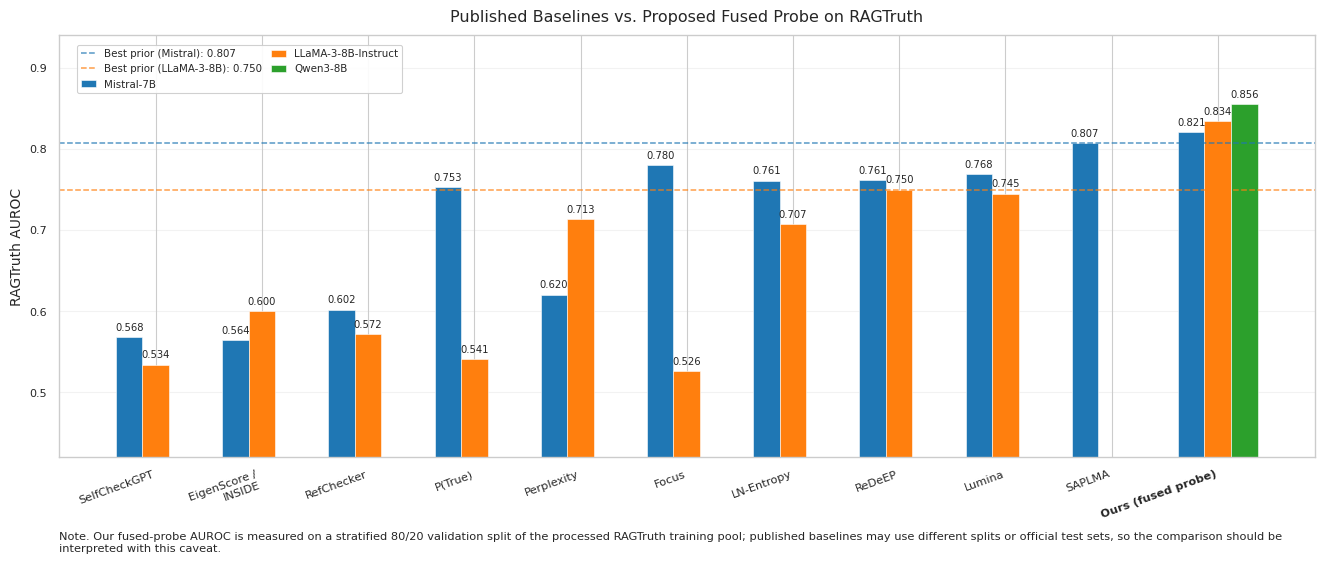

Saved outputs/compare_prior_work_ragtruth_paper_style.png


In [14]:
import os
os.makedirs("outputs", exist_ok=True)

import textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rows = [
    {"method": "SelfCheckGPT", "type": "Unsupervised", "mistral": 0.5680, "llama3_8b": 0.5339, "qwen3_8b": np.nan},
    {"method": "EigenScore / INSIDE", "type": "Unsupervised", "mistral": 0.5642, "llama3_8b": 0.6001, "qwen3_8b": np.nan},
    {"method": "RefChecker", "type": "Reference-based", "mistral": 0.6017, "llama3_8b": 0.5718, "qwen3_8b": np.nan},
    {"method": "P(True)", "type": "Verbalization", "mistral": 0.7530, "llama3_8b": 0.5407, "qwen3_8b": np.nan},
    {"method": "Perplexity", "type": "Unsupervised", "mistral": 0.6200, "llama3_8b": 0.7130, "qwen3_8b": np.nan},
    {"method": "Focus", "type": "Unsupervised", "mistral": 0.7803, "llama3_8b": 0.5258, "qwen3_8b": np.nan},
    {"method": "LN-Entropy", "type": "Unsupervised", "mistral": 0.7607, "llama3_8b": 0.7072, "qwen3_8b": np.nan},
    {"method": "ReDeEP", "type": "Unsupervised", "mistral": 0.7615, "llama3_8b": 0.7495, "qwen3_8b": np.nan},
    {"method": "Lumina", "type": "Unsupervised", "mistral": 0.7685, "llama3_8b": 0.7446, "qwen3_8b": np.nan},
    {"method": "SAPLMA", "type": "Supervised", "mistral": 0.8073, "llama3_8b": np.nan, "qwen3_8b": np.nan},
    {"method": "Ours (fused probe)", "type": "Supervised", "mistral": 0.8207, "llama3_8b": 0.8337, "qwen3_8b": 0.8555},
]

df = pd.DataFrame(rows)

mask_ours = df["method"] == "Ours (fused probe)"

# Load optional external AUROC values if available
for slug, col in [
    ("mistral-7b", "mistral"),
    ("llama-3-8b-instruct", "llama3_8b"),
    ("qwen3-8b", "qwen3_8b"),
]:
    for base in ("outputs", "."):
        p = os.path.join(base, f"model_results_{slug}.csv")

        if not os.path.isfile(p):
            continue

        d = pd.read_csv(p)

        if "fused_val_auroc" in d.columns and len(d) > 0:
            v = float(d.iloc[0]["fused_val_auroc"])

            if v > 0:
                df.loc[mask_ours, col] = v

        break

print(df.to_string(index=False))

# Best prior baseline values (excluding ours)
prior_only = df[~mask_ours]

best_m = float(np.nanmax(prior_only["mistral"].values))
best_l = float(np.nanmax(prior_only["llama3_8b"].values))

q_prior = prior_only["qwen3_8b"].astype(float)
q_prior = q_prior[~np.isnan(q_prior)]

best_q = float(np.nanmax(q_prior)) if len(q_prior) else float("nan")

# Plot setup
x = np.arange(len(df))
w = 0.25

fig, ax = plt.subplots(figsize=(13.8, 6.2))

# Bars
bars_m = ax.bar(
    x - w,
    df["mistral"],
    width=w,
    label="Mistral-7B",
    color="#1f77b4",
    edgecolor="white",
    linewidth=0.4,
)

bars_l = ax.bar(
    x,
    df["llama3_8b"],
    width=w,
    label="LLaMA-3-8B-Instruct",
    color="#ff7f0e",
    edgecolor="white",
    linewidth=0.4,
)

bars_q = ax.bar(
    x + w,
    df["qwen3_8b"],
    width=w,
    label="Qwen3-8B",
    color="#2ca02c",
    edgecolor="white",
    linewidth=0.4,
)

# Prior baseline reference lines
ax.axhline(
    best_m,
    color="#1f77b4",
    linestyle="--",
    linewidth=1.1,
    alpha=0.75,
    label=f"Best prior (Mistral): {best_m:.3f}",
)

ax.axhline(
    best_l,
    color="#ff7f0e",
    linestyle="--",
    linewidth=1.1,
    alpha=0.75,
    label=f"Best prior (LLaMA-3-8B): {best_l:.3f}",
)

if not np.isnan(best_q):
    ax.axhline(
        best_q,
        color="#2ca02c",
        linestyle="--",
        linewidth=1.1,
        alpha=0.75,
        label=f"Best prior (Qwen): {best_q:.3f}",
    )

# Value labels
def _label_bars_inside(bars):
    for b in bars:
        h = b.get_height()

        if h is None or np.isnan(h):
            continue

        y = min(h + 0.006, 0.925)

        ax.text(
            b.get_x() + b.get_width() / 2,
            y,
            f"{h:.3f}",
            ha="center",
            va="bottom",
            fontsize=7.2,
            clip_on=True,
        )

_label_bars_inside(bars_m)
_label_bars_inside(bars_l)
_label_bars_inside(bars_q)

# Wrap labels except ours
wrapped_labels = [
    label if label == "Ours (fused probe)"
    else textwrap.fill(label, width=13)
    for label in df["method"]
]

ax.set_xticks(x)

ax.set_xticklabels(
    wrapped_labels,
    rotation=20,
    ha="right",
    fontsize=8.2,
)

# Bold only ours
for tick, method in zip(ax.get_xticklabels(), df["method"]):
    if method == "Ours (fused probe)":
        tick.set_fontweight("bold")

# Axes styling
ax.set_ylabel("RAGTruth AUROC", fontsize=10)

ax.set_ylim(0.42, 0.94)

ax.grid(True, axis="y", alpha=0.25)

ax.set_axisbelow(True)

# Title
ax.set_title(
    "Published Baselines vs. Proposed Fused Probe on RAGTruth",
    fontsize=11.5,
    pad=10,
)

# Compact legend
ax.legend(
    loc="upper left",
    bbox_to_anchor=(0.01, 0.99),
    ncol=2,
    fontsize=7.4,
    frameon=True,
    framealpha=0.92,
    borderpad=0.4,
    handlelength=1.5,
    columnspacing=0.8,
)

# Optional watermark
ax.text(
    0.99,
    0.04,
    "",
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=8,
    alpha=0.28,
)

# Footnote
footnote = (
    "Note. Our fused-probe AUROC is measured on a stratified 80/20 validation split "
    "of the processed RAGTruth training pool; published baselines may use different "
    "splits or official test sets, so the comparison should be interpreted with this caveat."
)

# Reduce graph-footnote spacing
fig.subplots_adjust(
    left=0.075,
    right=0.985,
    top=0.89,
    bottom=0.21,
)

# Footnote text
fig.text(
    0.075,
    0.055,
    textwrap.fill(footnote, width=220),
    ha="left",
    va="bottom",
    fontsize=8.2,
)

# Save figure
out_fp = "outputs/compare_prior_work_ragtruth_paper_style.png"

plt.savefig(
    out_fp,
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.08,
)

plt.show()

print("Saved", out_fp)

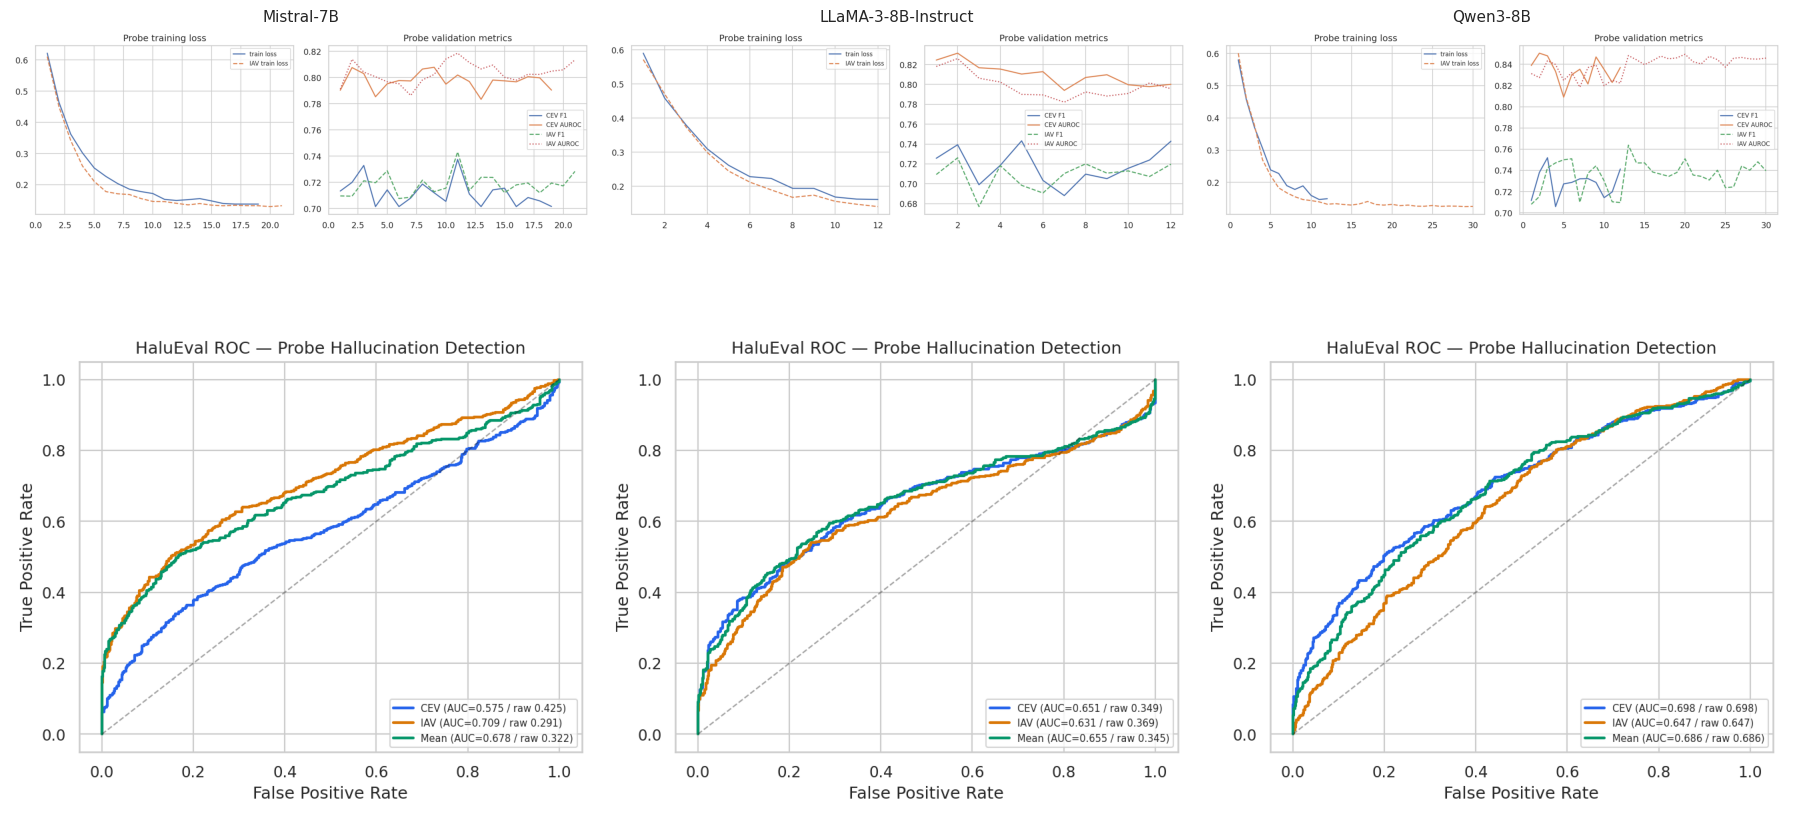

Saved /kaggle/working/outputs/compare_training_and_halueval_grid.png


In [16]:
from pathlib import Path
import matplotlib.image as mpimg
import matplotlib.pyplot as plt

# Input directory (read-only)
input_dir = Path("/kaggle/input/datasets/asgormumin57/model-result")
if not input_dir.exists():
    input_dir = Path("outputs")  # fallback for local testing

# Output directory (writable)
output_dir = Path("/kaggle/working")
output_dir.mkdir(exist_ok=True)

# Mapping from full model slug to filename prefix
slug_to_prefix = {
    "mistral-7b": "mistral",
    "llama-3-8b-instruct": "llama",
    "qwen3-8b": "qwen"
}

slugs = ["mistral-7b", "llama-3-8b-instruct", "qwen3-8b"]
plot_files = ["probe_training_curves.png", "halueval_roc.png"]
col_titles = ["Mistral-7B", "LLaMA-3-8B-Instruct", "Qwen3-8B"]

def resolve_png(slug: str, fname: str) -> Path | None:
    prefix = slug_to_prefix.get(slug, slug.split('-')[0])  # fallback
    # Build expected filename: e.g., llama_probe_training_curves.png
    candidate = input_dir / f"{prefix}_{fname}"
    if candidate.is_file():
        return candidate
    # Additional fallback patterns (just in case)
    alt_candidates = [
        input_dir / f"{slug}_{fname}",
        input_dir / fname.replace(".png", f"_{slug}.png"),
        input_dir / slug / fname,
    ]
    for c in alt_candidates:
        if c.is_file():
            return c
    return None

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for j, slug in enumerate(slugs):
    for i, fn in enumerate(plot_files):
        ax = axes[i, j]
        ax.axis("off")
        p = resolve_png(slug, fn)
        if p is None:
            ax.text(0.5, 0.5, f"missing image:\n{slug}\n{fn}",
                    ha="center", va="center", fontsize=10)
            continue
        ax.imshow(mpimg.imread(p))
        if i == 0:
            ax.set_title(col_titles[j], fontsize=11)


plt.tight_layout()

out_fp = output_dir / "outputs/compare_training_and_halueval_grid.png"
plt.savefig(out_fp, dpi=150, bbox_inches="tight")
plt.show()
print("Saved", out_fp)

### Training curves + HaluEval ROC (interpretation)

- **Smooth val AUROC / loss** in the top row indicates healthy probe optimisation on RAGTruth-processed labels (checkpoint = best **val AUROC**, not lowest train loss).
- **HaluEval ROC (bottom row)** is **cross-distribution**: Mistral and LLaMA often show **raw** curves **below** the diagonal until the notebook applies **polarity-aware** handling — compare raw vs flipped AUROC in each backbone log when reporting.
- **Ranking:** Qwen’s HaluEval ROC tends to sit **highest** in raw form in our April 2026 runs (**strongest OOD transfer** in this trio); LLaMA’s flipped mean AUROC is **useful but modest** (~0.65); Mistral sits **between**, with the flip visibly correcting inverted ranking.
